In [ ]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [ ]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\_aromatic_2025_8006_REST.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
0,"Phenol, 2,6-dibromo-4-(4-morpholylthiocarbonyl)-",C11H11Br2NO2S,379,294876-42-9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Oc1c(Br)cc(cc1Br)C(=S)N2CCOCC2,BrCHNOS
1,"Ethanone, 1-[2-(4-bromophenyl)-4-(hydroxymethy...",C12H10BrNO2S,311,67387-05-7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(=O)c1sc(nc1CO)c2ccc(Br)cc2,BrCHNOS
2,"Ethanone, 1-[2-(4-bromophenyl)-4-methyl-5-thia...",C12H10BrNOS,295,71338-62-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(=O)c1sc(nc1C)c2ccc(Br)cc2,BrCHNOS
3,"Acetamide, N-[4-acetyl-5-(5-bromothiophen-2-yl...",C10H10BrN3O2S2,347,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(=O)NC1=NN(C(S1)c2sc(Br)cc2)C(C)=O,BrCHNOS
4,1-(4-Bromo-phenyl)-3-(tetrahydro-furan-2-ylmet...,C12H15BrN2OS,314,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Brc1ccc(NC(=S)NCC2CCCO2)cc1,BrCHNOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8001,5-Iodo-2-trimethylsilyloxy-acetophenone,C11H15IO2Si,334,97389-64-5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(=O)c1cc(I)ccc1O[Si](C)(C)C,CHIOSi
8002,Bis(trimethylsilyl) 4-chlorophenylphosphonate,C12H22ClO3PSi2,336,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,C[Si](C)(C)O[P](=O)(O[Si](C)(C)C)c1ccc(Cl)cc1,CClHOPSi
8003,"Benzene, 1,1'-thiobis[2,3,4,5-tetrafluoro-6-iodo-",C12F8I2S,582,19638-37-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Fc1c(F)c(F)c(Sc2c(F)c(F)c(F)c(F)c2I)c(I)c1F,CFIS
8004,"Terephthaloyl chloride, tetrabromo-",C8Br4Cl2O2,514,54120-56-8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,ClC(=O)c1c(Br)c(Br)c(C(Cl)=O)c(Br)c1Br,BrCClO


In [ ]:
import deepchem as dc
import selfies as sf
import pandas as pd
X = ms.iloc[:, 4:604]     # spectra
y = ms.iloc[:, 605]       # smiles

se = []
dr = []  # list of indices to drop
c = 0

# Check all SMILES and filter out invalid/unsupported ones
for i in y:
    try:
        selfies_str = sf.encoder(i)
        se.append(selfies_str)
        if '.' in selfies_str:  # check for multi-molecule SMILES
            dr.append(c)
    except Exception as e:
        # Add to drop list if encoding fails (chemically invalid SMILES)
        dr.append(c)
    c += 1

# Drop problematic rows from original DataFrame
ms_cleaned = ms.drop(index=ms.index[dr]).reset_index(drop=True)

# Extract cleaned spectra and SMILES
X_clean = ms_cleaned.iloc[:, 4:604].to_numpy()
y_clean = ms_cleaned.iloc[:, 605].to_numpy()

# Create DeepChem dataset
ds = dc.data.DiskDataset.from_numpy(X_clean, y_clean)
ds

<DiskDataset X.shape: (np.int64(8001), np.int64(600)), y.shape: (np.int64(8001),), w.shape: (np.int64(8001),), task_names: [0]>

In [5]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[#N]': 3,
 '[/-Ring1]': 4,
 '[/Br]': 5,
 '[/C]': 6,
 '[/Cl]': 7,
 '[/F]': 8,
 '[/N]': 9,
 '[/O]': 10,
 '[/PH0]': 11,
 '[/P]': 12,
 '[/SH0]': 13,
 '[/S]': 14,
 '[=Branch1]': 15,
 '[=Branch2]': 16,
 '[=CH0]': 17,
 '[=C]': 18,
 '[=N+1]': 19,
 '[=N-1]': 20,
 '[=N]': 21,
 '[=O]': 22,
 '[=PH0]': 23,
 '[=PH1]': 24,
 '[=P]': 25,
 '[=Ring1]': 26,
 '[=Ring2]': 27,
 '[=SH0]': 28,
 '[=S]': 29,
 '[Br]': 30,
 '[Branch1]': 31,
 '[Branch2]': 32,
 '[C@@H1]': 33,
 '[C@@]': 34,
 '[C@H1]': 35,
 '[C@]': 36,
 '[CH0]': 37,
 '[CH1]': 38,
 '[CH2]': 39,
 '[C]': 40,
 '[Cl]': 41,
 '[F]': 42,
 '[I]': 43,
 '[N+1]': 44,
 '[N-1]': 45,
 '[NH1]': 46,
 '[N]': 47,
 '[O-1]': 48,
 '[O]': 49,
 '[P@@]': 50,
 '[PH0]': 51,
 '[PH1]': 52,
 '[P]': 53,
 '[Ring1]': 54,
 '[Ring2]': 55,
 '[SH0]': 56,
 '[S]': 57,
 '[SiH1]': 58,
 '[SiH2]': 59,
 '[SiH3]': 60,
 '[Si]': 61,
 '[\\-Ring1]': 62,
 '[\\C]': 63,
 '[\\Cl]': 64,
 '[\\I]': 65,
 '[\\N]': 66,
 '[\\O]': 67,
 '[\\PH0]': 68,
 '[\\P]': 6

In [6]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [7]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 7097
📦 Validation set size: 0
📦 Test set size: 904


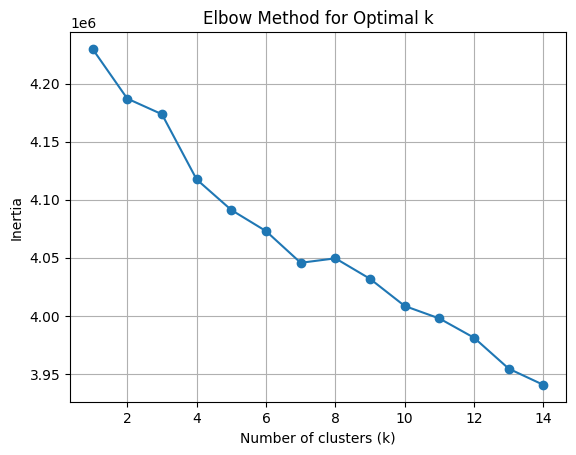

🔍 Elbow point detected at k = 7


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [9]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=7,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=7)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  m

In [10]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(7):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (590, 600)
Cluster 1 shape: (4722, 600)
Cluster 2 shape: (234, 600)
Cluster 3 shape: (286, 600)
Cluster 4 shape: (996, 600)
Cluster 5 shape: (113, 600)
Cluster 6 shape: (156, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  m

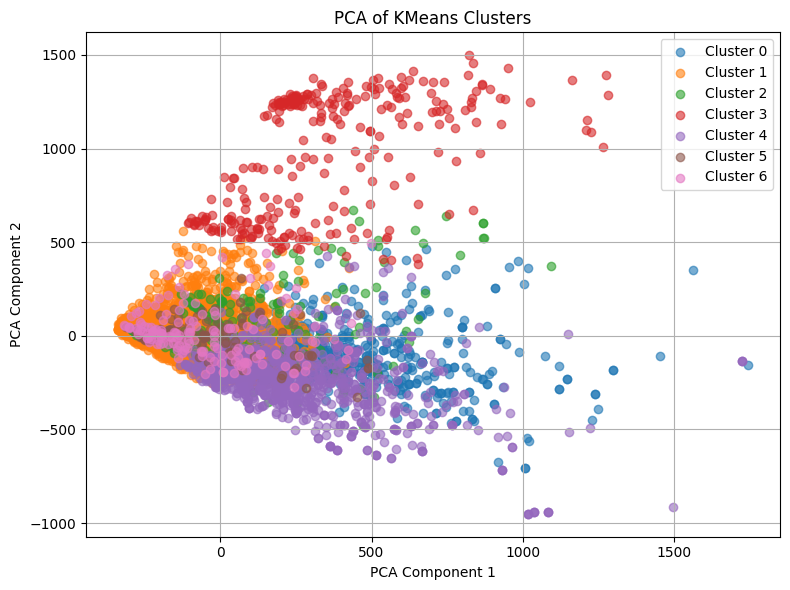

In [11]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=7)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [12]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [13]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")





✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indice

Cluster 0: size = 66, shape = (66, 600)
Cluster 1: size = 613, shape = (613, 600)
Cluster 2: size = 20, shape = (20, 600)
Cluster 3: size = 39, shape = (39, 600)
Cluster 4: size = 132, shape = (132, 600)
Cluster 5: size = 12, shape = (12, 600)
Cluster 6: size = 22, shape = (22, 600)


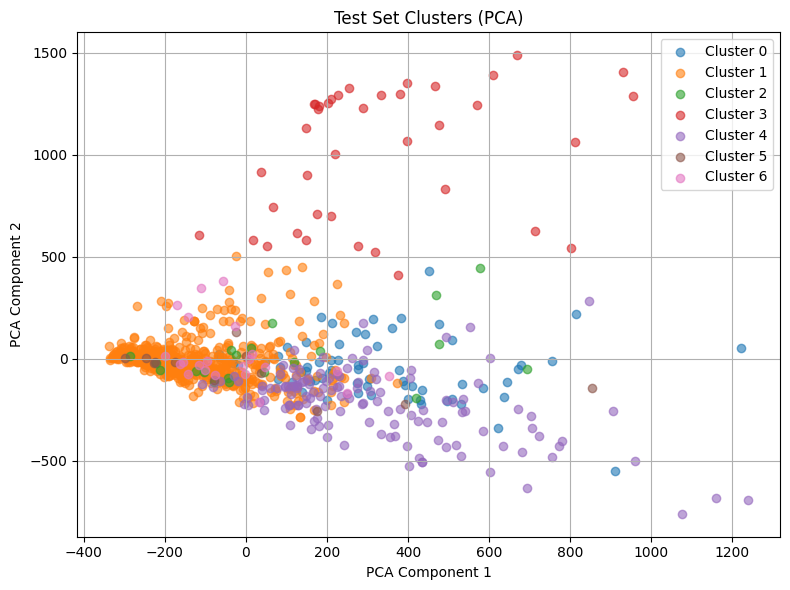

In [14]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(7):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 0.368980
Epoch 2/100 - Loss: 0.032555
Epoch 3/100 - Loss: 0.023522
Epoch 4/100 - Loss: 0.022077
Epoch 5/100 - Loss: 0.020963
Epoch 6/100 - Loss: 0.019930
Epoch 7/100 - Loss: 0.019109
Epoch 8/100 - Loss: 0.018204
Epoch 9/100 - Loss: 0.017256
Epoch 10/100 - Loss: 0.016246
Epoch 11/100 - Loss: 0.015282
Epoch 12/100 - Loss: 0.014188
Epoch 13/100 - Loss: 0.013291
Epoch 14/100 - Loss: 0.012317
Epoch 15/100 - Loss: 0.011476
Epoch 16/100 - Loss: 0.010638
Epoch 17/100 - Loss: 0.009213
Epoch 18/100 - Loss: 0.009053
Epoch 19/100 - Loss: 0.008322
Epoch 20/100 - Loss: 0.007738
Epoch 21/100 - Loss: 0.007109
Epoch 22/100 - Loss: 0.006439
Epoch 23/100 - Loss: 0.006107
Epoch 24/100 - Loss: 0.005533
Epoch 25/100 - Loss: 0.005154
Epoch 26/100 - Loss: 0.004666
Epoch 27/100 - Loss: 0.004355
Epoch 28/100 - Loss: 0.004227
Epoch 29/100 - Loss: 0.003893
Epoch 30/100 - Loss: 0.003553
Epoch 31/100 - Loss: 0.003333
Epoch 32/100 - Loss: 0.003065
Epoch 33/100 - Loss: 0.002873
Epoch 34/100 - Loss

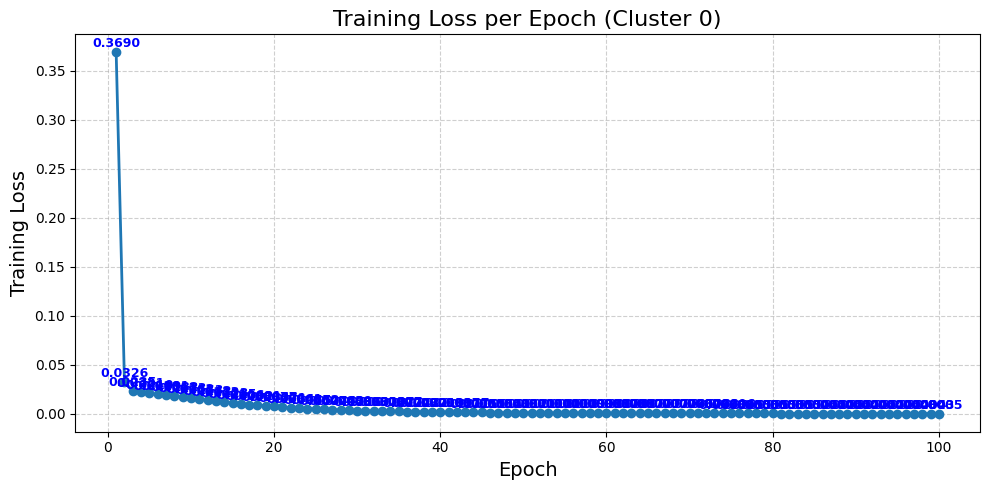

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\models_\model0000


In [15]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [16]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [17]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (66, 5616, 2)
Example prediction: [[9.9999976e-01 2.5253900e-07]
 [1.0000000e+00 2.9520285e-08]
 [9.9999976e-01 2.5665881e-07]
 ...
 [9.9999988e-01 1.5188242e-07]
 [1.0000000e+00 1.7534749e-08]
 [8.5304297e-09 1.0000000e+00]]


In [18]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [19]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [20]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: C=CC=CC=CCN(C)C=CC | True: CC1=CC(Br)=CC=C1N2C(=NC3=CC=CC=C3C2=O)S | Tanimoto: 0.041
[1] Pred: CI | True: CN1C(=C(C(=O)NC=2SC3=CC(Br)=CC=C3N=2)C(=O)C4=CC=CC=C14)O | Tanimoto: 0.002
[2] Pred: C1CCC1C=O | True: [O-1][N+1](=O)C1=CC=C(NN=C2C(=O)N(N=C2CSC3=CC=C(Br)C=C3)C4=CC=CC=C4)C=C1 | Tanimoto: 0.026
[3] Pred: IC1=CC=C(NC(=S)NC(=O)C2=CC=CN=C2)C=C1 | True: IC1=CC=C(NC(=S)NC(=O)C2=CC=CN=C2)C=C1 | Tanimoto: 1.000
[4] Pred: CNC=C(CC)CC=CC | True: CC1=CC=CC=C1NC(=O)C(Br)(C(F)(F)F)C(F)(F)F | Tanimoto: 0.046
[5] Pred: CCCCCCC=CC=CC=CC=CC=CCCF | True: CC1=CC=C(NC(=O)CN2N=NC(=N2)C3=CC=CC=C3F)C=C1Br | Tanimoto: 0.033
[6] Pred: FC1=CC(Br)=CC=C1NNC(=O)CC=CC=CC=O | True: FC1=CC=C(N2NC(=O)C3=CC=CC=C3C2=O)C(Br)=C1 | Tanimoto: 0.204
[7] Pred: FC=CC=C(C)C1CC=CC=C1C | True: CCOC(=O)C1=CC=CC=C1I | Tanimoto: 0.072
[8] Pred: IC=CC=C1C(C)C=C=C1CC | True: COC(=O)C1=CC=C(/C=C/C(=O)C2=CC=C(I)C=C2)C=C1 | Tanimoto: 0.086
[9] Pred: CC=CC=CNC=CCC=CCC | True: FC(F)(F)C1=CC(=NC(Cl)=C1C#N)C2=CC=CC=C2 | Tanimo

Epoch 1/100 - Loss: 0.062973
Epoch 2/100 - Loss: 0.020165
Epoch 3/100 - Loss: 0.018679
Epoch 4/100 - Loss: 0.017608
Epoch 5/100 - Loss: 0.016886
Epoch 6/100 - Loss: 0.016067
Epoch 7/100 - Loss: 0.015215
Epoch 8/100 - Loss: 0.014676
Epoch 9/100 - Loss: 0.013947
Epoch 10/100 - Loss: 0.013311
Epoch 11/100 - Loss: 0.012676
Epoch 12/100 - Loss: 0.012060
Epoch 13/100 - Loss: 0.011679
Epoch 14/100 - Loss: 0.011038
Epoch 15/100 - Loss: 0.010491
Epoch 16/100 - Loss: 0.009992
Epoch 17/100 - Loss: 0.009581
Epoch 18/100 - Loss: 0.009018
Epoch 19/100 - Loss: 0.008596
Epoch 20/100 - Loss: 0.008187
Epoch 21/100 - Loss: 0.007363
Epoch 22/100 - Loss: 0.007444
Epoch 23/100 - Loss: 0.006758
Epoch 24/100 - Loss: 0.006762
Epoch 25/100 - Loss: 0.006450
Epoch 26/100 - Loss: 0.006237
Epoch 27/100 - Loss: 0.005971
Epoch 28/100 - Loss: 0.005843
Epoch 29/100 - Loss: 0.005572
Epoch 30/100 - Loss: 0.005520
Epoch 31/100 - Loss: 0.005225
Epoch 32/100 - Loss: 0.005091
Epoch 33/100 - Loss: 0.004935
Epoch 34/100 - Loss

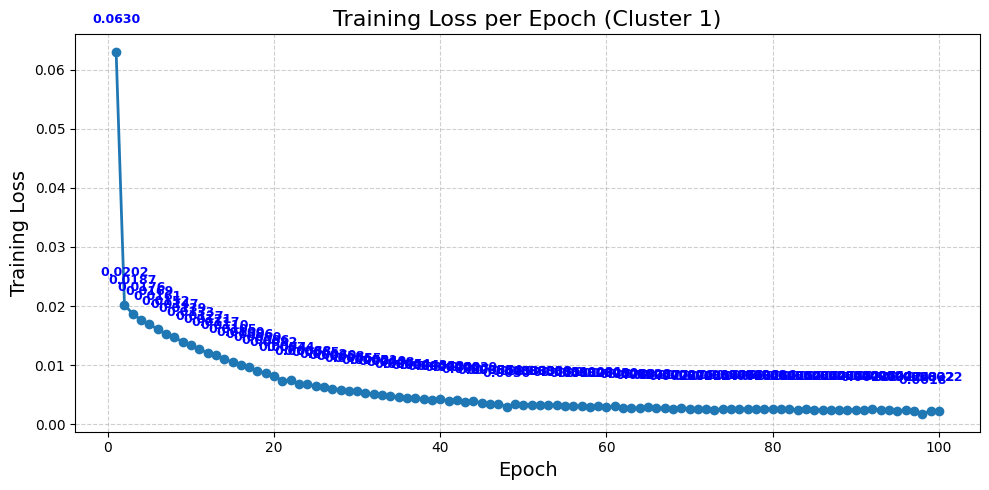

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\models_\model1111


In [21]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [22]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (613, 5616, 2)
Example prediction: [[1.0000000e+00 4.4247201e-12]
 [1.0000000e+00 4.4600703e-12]
 [1.0000000e+00 4.2091682e-12]
 ...
 [1.0000000e+00 1.6555122e-11]
 [1.0000000e+00 3.9857076e-12]
 [4.9135878e-12 1.0000000e+00]]
[0] Pred: FC=CC=CC=C=NNCCC | True: BrC1=CN2SC(=NC(=O)C=3OC=CC=3)N=C2C=C1 | Tanimoto: 0.051
[1] Pred: C(C)(C1)=C1C(=O)CNCC2=CC=NC=C2 | True: BrC1=CC=C(C=C1)[SH0](=O)(=O)NCCC2=CC=NC=C2 | Tanimoto: 0.185
[2] Pred: C1=CC=C(C=C1)[SH0](=O)(=O)NC=CC=CC | True: BrC1=CC=C(C=C1)[SH0](=O)(=O)NC2=CC=CC=C2 | Tanimoto: 0.339
[3] Pred: FCC=C(CC)CF | True: C[SH0](=O)(=O)N1CCC2=CC(Br)=CC=C12 | Tanimoto: 0.027
[4] Pred: O(C)C1COCC=CCCC=C=CC=C=C1O | True: BrC12CC3CC(C1)CC(C3)(C2)C(=O)NCCC=4SC=CC=4 | Tanimoto: 0.092
[5] Pred: CCCCCCCCC=CC=CC=C | True: BrC1=CC=C(NC(=S)C=2OC=CC=2)C=C1 | Tanimoto: 0.026
[6] Pred: C=CC=CC(C)CCC=CCCC=CC | True: BrC(=NNC1=CC=CC=C1)C(=O)C2=CSC=C2 | Tanimoto: 0.033
[7] Pred: CCCC/CC(C)=CC=CC | True: NC1=CC=CC=C1SC2=CC=C(Br)C=C2[N+1]([O-1

[13:23:02] Explicit valence for atom # 1 Si, 7, is greater than permitted


[479] Pred: CCOC(=O)/C(=C/C=C1C=CC(F)C=C1)[PH0](=O)(OCC)OCC | True: CCOC(=O)C(=CC1=CC=CC(F)=C1)[PH0](=O)(OCC)OCC | Tanimoto: 0.471
[480] Pred: CC(C)(C)CC=CCC(C)C(C)C(C)CC=CI | True: CC(C)(C)CC1=CC(CC(C)(C)C)=C(I)C(CC(C)(C)C)=C1Br | Tanimoto: 0.060
[481] Pred: BrC1=CC=CC=C1I | True: BrC1=CC=C(I)C=C1 | Tanimoto: 0.677
[482] Pred: CC | True: BrC1=CC=2SC3=CC(Br)=C(Br)C=C3SC=2C=C1Br | Tanimoto: 0.000
[483] Pred: CSC1=CC=C(Br)C=C1 | True: CSC1=CC=CC=C1Br | Tanimoto: 0.644
[484] Pred: C=[PH0](N=N[PH0](=N)CCl)Cl | True: BrC1=CC=C2SC(=CC2=C1)C=3SC4=CC=C(Br)C=C4C=3 | Tanimoto: 0.042
[485] Pred: C1CCCC(=C)C1CCC | True: IC1=CSC2=NC3=CC=CC=C3C=C12 | Tanimoto: 0.034
[486] Pred: NC1=CC=C(C=C1)C=2SC(N)=NC=2C3=CC=C(I)C=C3 | True: NC1=CC=C(C=C1)C=2SC(N)=NC=2C3=CC=CC(I)=C3 | Tanimoto: 0.894
[487] Pred: C[Si](C)(C)OC=C1C=C(Cl)C(=CC1)Cl | True: C[Si](C)(C)OC1=CC(Cl)=C(C=C1Cl)C2=CC(Cl)=CC=C2Cl | Tanimoto: 0.108
[488] Pred: COC=CC=C(C)CCO[SiH1]C=C | True: COC1=CC=C(CO[Si](C)(C)CCCCl)C=C1 | Tanimoto: 0.069
[4

Epoch 1/100 - Loss: 0.626200
Epoch 2/100 - Loss: 0.041384
Epoch 3/100 - Loss: 0.034395
Epoch 4/100 - Loss: 0.023731
Epoch 5/100 - Loss: 0.018191
Epoch 6/100 - Loss: 0.015349
Epoch 7/100 - Loss: 0.014534
Epoch 8/100 - Loss: 0.014002
Epoch 9/100 - Loss: 0.013498
Epoch 10/100 - Loss: 0.013076
Epoch 11/100 - Loss: 0.012477
Epoch 12/100 - Loss: 0.012056
Epoch 13/100 - Loss: 0.011418
Epoch 14/100 - Loss: 0.010929
Epoch 15/100 - Loss: 0.010396
Epoch 16/100 - Loss: 0.009878
Epoch 17/100 - Loss: 0.009296
Epoch 18/100 - Loss: 0.008773
Epoch 19/100 - Loss: 0.008416
Epoch 20/100 - Loss: 0.007858
Epoch 21/100 - Loss: 0.007512
Epoch 22/100 - Loss: 0.006938
Epoch 23/100 - Loss: 0.006589
Epoch 24/100 - Loss: 0.006176
Epoch 25/100 - Loss: 0.005728
Epoch 26/100 - Loss: 0.005440
Epoch 27/100 - Loss: 0.005153
Epoch 28/100 - Loss: 0.004891
Epoch 29/100 - Loss: 0.004557
Epoch 30/100 - Loss: 0.004463
Epoch 31/100 - Loss: 0.004120
Epoch 32/100 - Loss: 0.003800
Epoch 33/100 - Loss: 0.003753
Epoch 34/100 - Loss

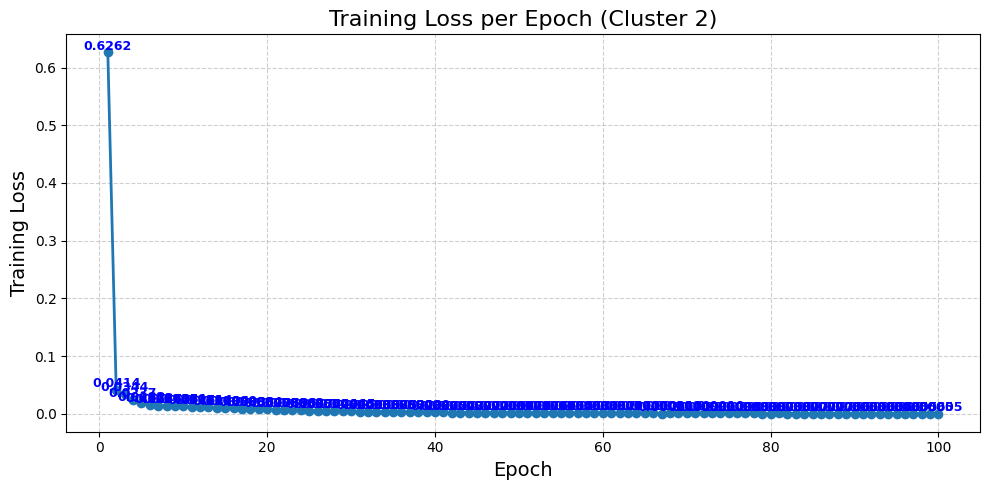

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\models_\model2222


In [23]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [24]:
# === Load cluster 2 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 2
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_2
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])

evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (20, 5616, 2)
Example prediction: [[1.0000000e+00 1.0490462e-09]
 [1.0000000e+00 6.4845573e-10]
 [1.0000000e+00 1.3776649e-09]
 ...
 [1.0000000e+00 1.2670093e-09]
 [1.0000000e+00 1.3759219e-08]
 [4.4030064e-09 1.0000000e+00]]
[0] Pred: Cl[SH0](=O)(=O)C1=CC=C(Br)C=C1 | True: ON[SH0](=O)(=O)C1=CC=C(Br)C=C1 | Tanimoto: 0.426
[1] Pred: C=C=C=C(N)CCCCC | True: COC(=O)C(CC=1[NH1]C=NC=1Br)NC(=O)C(F)(F)F | Tanimoto: 0.039
[2] Pred: C1=CC=C1C(C)OC#C | True: FC1=CC=C(C=C1)C=2ON=C(N=2)C=3OC(Br)=CC=3 | Tanimoto: 0.084
[3] Pred: COC(C)OCCC(C)C(F)=CC=CC=CC | True: COC(=O)C(SC1=C(O)C=C(C)OC1=O)(C(F)(F)F)C(F)(F)F | Tanimoto: 0.104
[4] Pred: C(C)CC=CC=CCCl | True: ClC1=CC=C(C=C1)[SH0](=O)C2=CC=CC=C2Cl | Tanimoto: 0.032
[5] Pred: ClC1=CC=C(C=C1)[SH0](=O)(=O)C2=CC(Cl)=C(Cl)C(Cl)=C2 | True: ClC1=CC=C(C=C1)[SH0](=O)(=O)C2=CC(Cl)=C(Cl)C=C2Cl | Tanimoto: 0.743
[6] Pred: CC(C1Cl)C=C=C1 | True: OC1C(C2=CC=C(Cl)C(Cl)=C2)[SH0](=O)(=O)C(C3=CC=C(Cl)C(Cl)=C3)C1=O | Tanimoto: 0.036
[7] Pred: CCCC

Epoch 1/100 - Loss: 0.668453
Epoch 2/100 - Loss: 0.055039
Epoch 3/100 - Loss: 0.040626
Epoch 4/100 - Loss: 0.028880
Epoch 5/100 - Loss: 0.022804
Epoch 6/100 - Loss: 0.021045
Epoch 7/100 - Loss: 0.020314
Epoch 8/100 - Loss: 0.019606
Epoch 9/100 - Loss: 0.018874
Epoch 10/100 - Loss: 0.018103
Epoch 11/100 - Loss: 0.017413
Epoch 12/100 - Loss: 0.016709
Epoch 13/100 - Loss: 0.016019
Epoch 14/100 - Loss: 0.015377
Epoch 15/100 - Loss: 0.014744
Epoch 16/100 - Loss: 0.014168
Epoch 17/100 - Loss: 0.013477
Epoch 18/100 - Loss: 0.013032
Epoch 19/100 - Loss: 0.012384
Epoch 20/100 - Loss: 0.011729
Epoch 21/100 - Loss: 0.011219
Epoch 22/100 - Loss: 0.010706
Epoch 23/100 - Loss: 0.010201
Epoch 24/100 - Loss: 0.009646
Epoch 25/100 - Loss: 0.009262
Epoch 26/100 - Loss: 0.008819
Epoch 27/100 - Loss: 0.008430
Epoch 28/100 - Loss: 0.008026
Epoch 29/100 - Loss: 0.007459
Epoch 30/100 - Loss: 0.007338
Epoch 31/100 - Loss: 0.006913
Epoch 32/100 - Loss: 0.006677
Epoch 33/100 - Loss: 0.006360
Epoch 34/100 - Loss

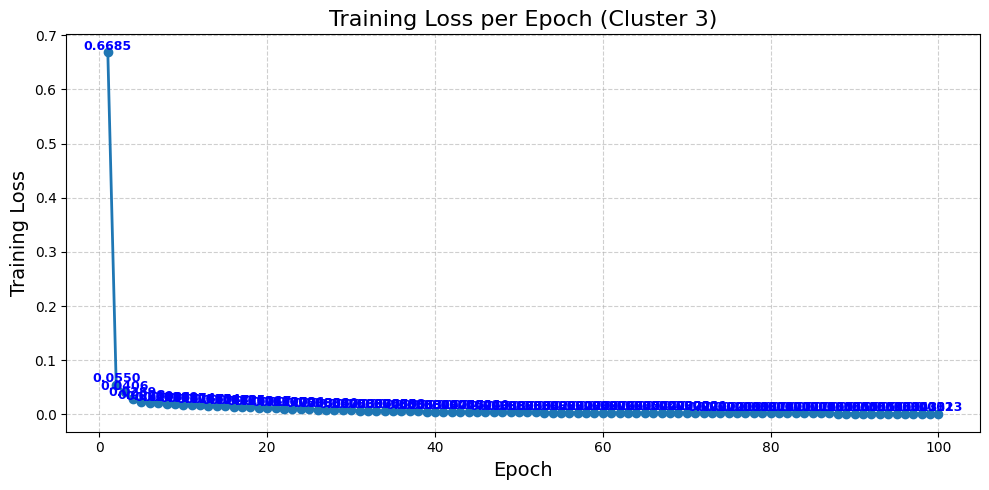

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\models_\model3333


In [25]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 3 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_3.pkl", "rb") as f:
    X_cluster3 = pickle.load(f)

cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_3_indices.npy")
y_cluster3 = train_dataset.y[cluster_3_indices]

if len(y_cluster3.shape) == 1:
    y_cluster3 = y_cluster3.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_3 = dc.data.NumpyDataset(X=np.array(X_cluster3), y=np.array(y_cluster3))

# === Model config
n_tasks = train_dataset_3.y.shape[1]
n_features = train_dataset_3.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_3 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\models_\model3333"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_3.fit(train_dataset_3, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 3)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_3.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [26]:
# === Load cluster 3 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3.pkl", "rb") as f:
    X_test_cluster3 = pickle.load(f)

# === Load corresponding indices
test_cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster3 = test_dataset.y[test_cluster_3_indices]

if len(y_test_cluster3.shape) == 1:
    y_test_cluster3 = y_test_cluster3.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 3
test_dataset_3 = dc.data.NumpyDataset(X=np.array(X_test_cluster3), y=np.array(y_test_cluster3))

# === Predict using the trained model_3
predictions_3 = model_3.predict(test_dataset_3)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_3.shape)
print("Example prediction:", predictions_3[0])

evaluate_flat_predictions(predictions_3, test_dataset_3, itos, sf, cutoff=0.5)


✅ Prediction shape: (39, 5616, 2)
Example prediction: [[1.0000000e+00 2.2738313e-08]
 [1.0000000e+00 5.8042946e-08]
 [9.9999976e-01 2.3929118e-07]
 ...
 [9.9999976e-01 2.9566192e-07]
 [9.9999964e-01 3.8255575e-07]
 [7.4522212e-08 9.9999988e-01]]
[0] Pred: C1=CC=C(CCCCC)CC=C1 | True: BrC1=CC=CC(=C1)C(=O)NC=2SC=3CCCC=3C=2C#N | Tanimoto: 0.063
[1] Pred: BrC1=CC=CC(=C1)C(=O)NC=2SC=CN=2 | True: BrC1=CC=C(C=C1)C(=O)NC=2SC=CN=2 | Tanimoto: 0.828
[2] Pred: CC1=CC=C(C)C(=C1)C=2SC(NC(=O)C3=CC=C(Br)C=C3)=NC=2 | True: CC1=CC=C(C(C)=C1)C=2SC(NC(=O)C3=CC=C(Br)C=C3)=NC=2 | Tanimoto: 0.904
[3] Pred: C=CC(=O)CSC(C)CC=CCBr | True: BrC1=CC=C(C=C1)C(=O)C2=NOC=C2C(=O)C=3SC=CC=3 | Tanimoto: 0.050
[4] Pred: C1C=CC=CCC=CCC=CC(=C)C1C2=CC=CCC2C=C=C | True: COC1=CC=C2N=C(NC(=O)COC(=O)C3=CC=CC=C3Br)SC2=C1 | Tanimoto: 0.114
[5] Pred: CC(C)C=CCCCC=CBr | True: FC(F)(F)C1=CC(=CC(=C1)C(F)(F)F)C(=O)C2=CC=C(Br)C=C2 | Tanimoto: 0.016
[6] Pred: ClF | True: FC1=CC(F)=CC(OC(=O)C2=CC=C(Br)C=C2)=C1 | Tanimoto: 0.003
[7] Pred:

Epoch 1/100 - Loss: 0.228495
Epoch 2/100 - Loss: 0.024181
Epoch 3/100 - Loss: 0.021904
Epoch 4/100 - Loss: 0.020714
Epoch 5/100 - Loss: 0.019794
Epoch 6/100 - Loss: 0.018792
Epoch 7/100 - Loss: 0.017734
Epoch 8/100 - Loss: 0.016819
Epoch 9/100 - Loss: 0.015903
Epoch 10/100 - Loss: 0.015027
Epoch 11/100 - Loss: 0.014222
Epoch 12/100 - Loss: 0.013465
Epoch 13/100 - Loss: 0.012703
Epoch 14/100 - Loss: 0.011955
Epoch 15/100 - Loss: 0.011218
Epoch 16/100 - Loss: 0.010467
Epoch 17/100 - Loss: 0.009797
Epoch 18/100 - Loss: 0.009141
Epoch 19/100 - Loss: 0.008566
Epoch 20/100 - Loss: 0.008068
Epoch 21/100 - Loss: 0.007543
Epoch 22/100 - Loss: 0.007012
Epoch 23/100 - Loss: 0.006503
Epoch 24/100 - Loss: 0.006106
Epoch 25/100 - Loss: 0.005662
Epoch 26/100 - Loss: 0.005246
Epoch 27/100 - Loss: 0.004903
Epoch 28/100 - Loss: 0.004647
Epoch 29/100 - Loss: 0.004332
Epoch 30/100 - Loss: 0.004063
Epoch 31/100 - Loss: 0.003805
Epoch 32/100 - Loss: 0.003643
Epoch 33/100 - Loss: 0.003452
Epoch 34/100 - Loss

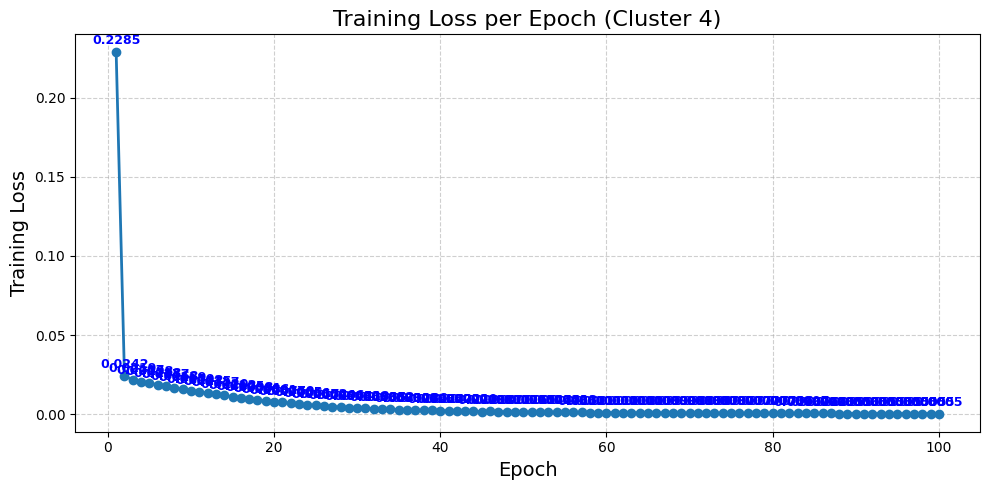

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\models_\model4444


In [27]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 4 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_4.pkl", "rb") as f:
    X_cluster4 = pickle.load(f)

cluster_4_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_4_indices.npy")
y_cluster4 = train_dataset.y[cluster_4_indices]

if len(y_cluster4.shape) == 1:
    y_cluster4 = y_cluster4.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_4 = dc.data.NumpyDataset(X=np.array(X_cluster4), y=np.array(y_cluster4))

# === Model config
n_tasks = train_dataset_4.y.shape[1]
n_features = train_dataset_4.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_4 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\models_\model4444"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_4.fit(train_dataset_4, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 4)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_4.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [28]:
# === Load cluster 4 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_4.pkl", "rb") as f:
    X_test_cluster4 = pickle.load(f)

# === Load corresponding indices
test_cluster_4_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_4_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster4 = test_dataset.y[test_cluster_4_indices]

if len(y_test_cluster4.shape) == 1:
    y_test_cluster4 = y_test_cluster4.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 4
test_dataset_4 = dc.data.NumpyDataset(X=np.array(X_test_cluster4), y=np.array(y_test_cluster4))

# === Predict using the trained model_4
predictions_4 = model_4.predict(test_dataset_4)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_4.shape)
print("Example prediction:", predictions_4[0])

evaluate_flat_predictions(predictions_4, test_dataset_4, itos, sf, cutoff=0.5)


✅ Prediction shape: (132, 5616, 2)
Example prediction: [[1.0000000e+00 2.5219318e-09]
 [1.0000000e+00 2.3625564e-09]
 [1.0000000e+00 1.0281408e-11]
 ...
 [1.0000000e+00 6.7261134e-09]
 [1.0000000e+00 5.6307120e-10]
 [1.6716145e-08 1.0000000e+00]]
[0] Pred: CC(=O)N1C(CSC1C2=CC=C(Br)C=C2)C(O)=O | True: CC(=O)N1C(CSC1C2=CC=C(Br)C=C2)C(O)=O | Tanimoto: 1.000
[1] Pred: CN1CN=C2SC(=CC3=CC=C(Br)C=C3)C(=O)N2C1 | True: CN1CN=C2SC(=CC3=CC=C(Br)C=C3)C(=O)N2C1 | Tanimoto: 1.000
[2] Pred: BrC1CCC2=C(SC=3N=C4CCCCCN4C(=O)C2=3)C1=O | True: BrC1CCC2=C(SC=3N=C4CCCCCN4C(=O)C2=3)C1=O | Tanimoto: 1.000
[3] Pred: O[SH0](=O)(=O)SCCNCCCCCCCCOC1=CC=C(Br)C=N1 | True: O[SH0](=O)(=O)SCCNCCCCCCCCOC1=CC=C(Br)C=N1 | Tanimoto: 1.000
[4] Pred: CCCCNNCCC(C1)C1 | True: OC(=O)CCSC=1[NH1]C(Br)=C(N=1)[N+1]([O-1])=O | Tanimoto: 0.037
[5] Pred: CCC(CCC=O)OC=CNC=CCCC=C=C | True: CC1=CC2=C(C(C=3SC(Br)=CC=3)C(=C(N)O2)C#N)C(=O)O1 | Tanimoto: 0.082
[6] Pred: CCC=O | True: CC(=O)NC1=CC=CC=C1SC2=CC=C(Br)C=C2[N+1]([O-1])=O | Tanimot

Epoch 1/100 - Loss: 0.823690
Epoch 2/100 - Loss: 0.033753
Epoch 3/100 - Loss: 0.031664
Epoch 4/100 - Loss: 0.030712
Epoch 5/100 - Loss: 0.024359
Epoch 6/100 - Loss: 0.016972
Epoch 7/100 - Loss: 0.014234
Epoch 8/100 - Loss: 0.012269
Epoch 9/100 - Loss: 0.011195
Epoch 10/100 - Loss: 0.010646
Epoch 11/100 - Loss: 0.010496
Epoch 12/100 - Loss: 0.010266
Epoch 13/100 - Loss: 0.010035
Epoch 14/100 - Loss: 0.009680
Epoch 15/100 - Loss: 0.009289
Epoch 16/100 - Loss: 0.009027
Epoch 17/100 - Loss: 0.008723
Epoch 18/100 - Loss: 0.008354
Epoch 19/100 - Loss: 0.007992
Epoch 20/100 - Loss: 0.007741
Epoch 21/100 - Loss: 0.007429
Epoch 22/100 - Loss: 0.007092
Epoch 23/100 - Loss: 0.006751
Epoch 24/100 - Loss: 0.006446
Epoch 25/100 - Loss: 0.006167
Epoch 26/100 - Loss: 0.005923
Epoch 27/100 - Loss: 0.005617
Epoch 28/100 - Loss: 0.005298
Epoch 29/100 - Loss: 0.005063
Epoch 30/100 - Loss: 0.004871
Epoch 31/100 - Loss: 0.004655
Epoch 32/100 - Loss: 0.004334
Epoch 33/100 - Loss: 0.004085
Epoch 34/100 - Loss

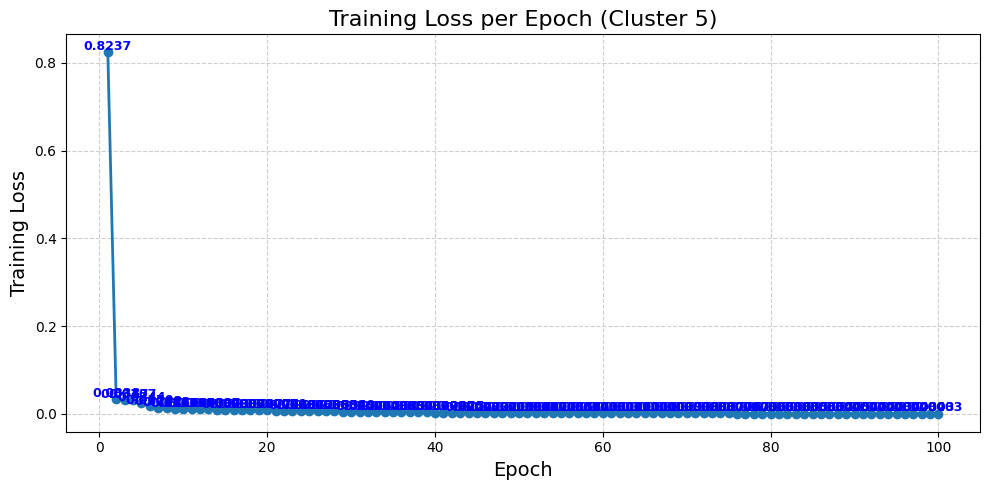

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\models_\model5555


In [29]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 5 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_5.pkl", "rb") as f:
    X_cluster5 = pickle.load(f)

cluster_5_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_5_indices.npy")
y_cluster5 = train_dataset.y[cluster_5_indices]

if len(y_cluster5.shape) == 1:
    y_cluster5 = y_cluster5.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_5 = dc.data.NumpyDataset(X=np.array(X_cluster5), y=np.array(y_cluster5))

# === Model config
n_tasks = train_dataset_5.y.shape[1]
n_features = train_dataset_5.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_5 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\models_\model5555"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_5.fit(train_dataset_5, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 5)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_5.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [30]:
# === Load cluster 5 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_5.pkl", "rb") as f:
    X_test_cluster5 = pickle.load(f)

# === Load corresponding indices
test_cluster_5_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_5_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster5 = test_dataset.y[test_cluster_5_indices]

if len(y_test_cluster5.shape) == 1:
    y_test_cluster5 = y_test_cluster5.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 5
test_dataset_5 = dc.data.NumpyDataset(X=np.array(X_test_cluster5), y=np.array(y_test_cluster5))

# === Predict using the trained model_5
predictions_5 = model_5.predict(test_dataset_5)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_5.shape)
print("Example prediction:", predictions_5[0])

evaluate_flat_predictions(predictions_5, test_dataset_5, itos, sf, cutoff=0.5)


✅ Prediction shape: (12, 5616, 2)
Example prediction: [[1.0000000e+00 1.2357129e-13]
 [1.0000000e+00 3.1597495e-13]
 [1.0000000e+00 9.5226318e-12]
 ...
 [1.0000000e+00 2.0344850e-16]
 [1.0000000e+00 1.4111746e-13]
 [4.1267906e-14 1.0000000e+00]]
[0] Pred: OC=C(CC)OCC | True: C[SH0](=O)(=NC(=S)NC1=CC=C(Br)C=C1)C2=CC=CC=C2 | Tanimoto: 0.016
[1] Pred: FC(F)(F)C1=CN=C(Cl)C(Cl)=C1 | True: FC(F)(F)C1=CC(Cl)=NC(Cl)=C1 | Tanimoto: 0.417
[2] Pred: CC(C)Cl | True: C[SH0](=O)(=O)C1=C(Cl)C(Cl)=CC(Cl)=C1Cl | Tanimoto: 0.010
[3] Pred: ClC=1SC(=CC=1Cl)[SH0](Cl)(=O)=O | True: ClC=1SC(Cl)=C(C=1)[SH0](Cl)(=O)=O | Tanimoto: 0.306
[4] Pred: BrNC1=CC=C=NCCC[NH1]C1 | True: CC1=CC(C)=C(Br)C(C)=C1N | Tanimoto: 0.076
[5] Pred: CCCCCCCCCCCCCCCCCCOC=CC=CCC=CC | True: CCCCCCCCCCCO[PH0](=O)(CCCC)OC1=CC=CC=C1Cl | Tanimoto: 0.070
[6] Pred: CCCCCCCCCCCCCCC(C)CCCCCC | True: CCCCCCCCCCCCCCO[PH0](=O)(CCCC)OC1=CC=CC=C1Cl | Tanimoto: 0.035
[7] Pred: C(C)C(C)OCC=C(C)CC | True: FC1=CC=C(S\C(=C\C=C(C#N)C#N)C2=CC=C(Cl)C=C2)C=

Epoch 1/100 - Loss: 0.858101
Epoch 2/100 - Loss: 0.037135
Epoch 3/100 - Loss: 0.042202
Epoch 4/100 - Loss: 0.033817
Epoch 5/100 - Loss: 0.025468
Epoch 6/100 - Loss: 0.020482
Epoch 7/100 - Loss: 0.018265
Epoch 8/100 - Loss: 0.017175
Epoch 9/100 - Loss: 0.016748
Epoch 10/100 - Loss: 0.016446
Epoch 11/100 - Loss: 0.016047
Epoch 12/100 - Loss: 0.015666
Epoch 13/100 - Loss: 0.015175
Epoch 14/100 - Loss: 0.014828
Epoch 15/100 - Loss: 0.014294
Epoch 16/100 - Loss: 0.013826
Epoch 17/100 - Loss: 0.013464
Epoch 18/100 - Loss: 0.013062
Epoch 19/100 - Loss: 0.012537
Epoch 20/100 - Loss: 0.012172
Epoch 21/100 - Loss: 0.011631
Epoch 22/100 - Loss: 0.010963
Epoch 23/100 - Loss: 0.010503
Epoch 24/100 - Loss: 0.009909
Epoch 25/100 - Loss: 0.009456
Epoch 26/100 - Loss: 0.008925
Epoch 27/100 - Loss: 0.008535
Epoch 28/100 - Loss: 0.008077
Epoch 29/100 - Loss: 0.007483
Epoch 30/100 - Loss: 0.007067
Epoch 31/100 - Loss: 0.006670
Epoch 32/100 - Loss: 0.006380
Epoch 33/100 - Loss: 0.005925
Epoch 34/100 - Loss

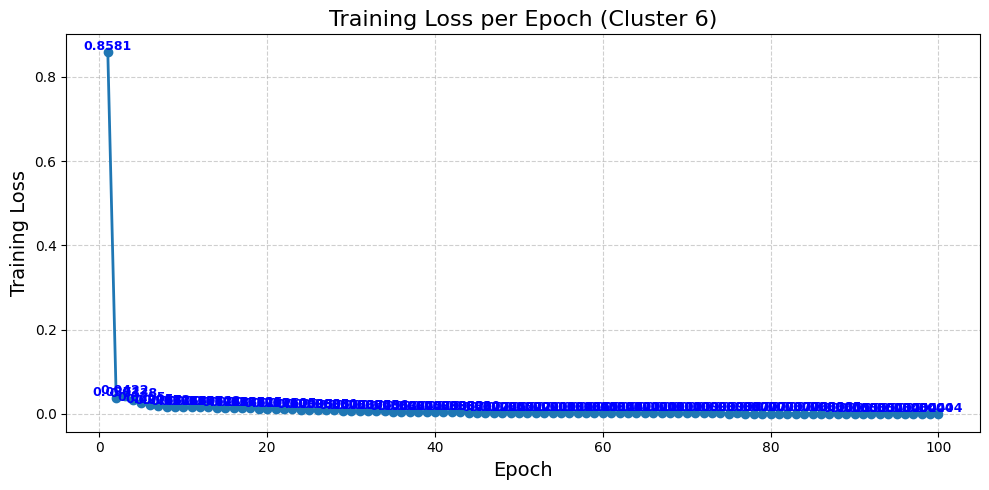

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\models_\model6666


In [31]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 6 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_6.pkl", "rb") as f:
    X_cluster6 = pickle.load(f)

cluster_6_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  seed 123\clustering_from_trainset\cluster_6_indices.npy")
y_cluster6 = train_dataset.y[cluster_6_indices]

if len(y_cluster6.shape) == 1:
    y_cluster6 = y_cluster6.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_6 = dc.data.NumpyDataset(X=np.array(X_cluster6), y=np.array(y_cluster6))

# === Model config
n_tasks = train_dataset_6.y.shape[1]
n_features = train_dataset_6.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_6 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with seed 123\models_\model6666"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_6.fit(train_dataset_6, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 6)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_6.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [32]:
# === Load cluster 6 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_6.pkl", "rb") as f:
    X_test_cluster6 = pickle.load(f)

# === Load corresponding indices
test_cluster_6_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_8006_REST\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_6_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster6 = test_dataset.y[test_cluster_6_indices]

if len(y_test_cluster6.shape) == 1:
    y_test_cluster6 = y_test_cluster6.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 6
test_dataset_6 = dc.data.NumpyDataset(X=np.array(X_test_cluster6), y=np.array(y_test_cluster6))

# === Predict using the trained model_6
predictions_6 = model_6.predict(test_dataset_6)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_6.shape)
print("Example prediction:", predictions_6[0])

evaluate_flat_predictions(predictions_6, test_dataset_6, itos, sf, cutoff=0.5)


✅ Prediction shape: (22, 5616, 2)
Example prediction: [[1.0000000e+00 3.0250998e-17]
 [1.0000000e+00 3.9285760e-18]
 [1.0000000e+00 3.4061092e-15]
 ...
 [1.0000000e+00 2.5275833e-18]
 [1.0000000e+00 1.0799511e-15]
 [9.6783937e-18 1.0000000e+00]]
[0] Pred: CC1=NN(CC2=C(F)C=CC=C2Cl)C(C)=C1N | True: CC1=NN(CC2=C(F)C=CC=C2Cl)C(C)=C1N | Tanimoto: 1.000
[1] Pred: CC(CCCO)CCCC=CCCC | True: CC(C1=CC=CC=C1[SH0](=O)(=O)OCF)[SH0](=O)(=O)C2=CC=C(C)C=C2 | Tanimoto: 0.037
[2] Pred: C=C(C)CCC=CC=CCCC=CC | True: CC=1SC2=CC=C(C=C2N=1)C(F)(F)F | Tanimoto: 0.024
[3] Pred: FC(F)(C)CCCCCCC=C | True: FC(F)(F)C=1[NH1]N=C(C=1)C=2SC=CC=2 | Tanimoto: 0.035
[4] Pred: FC(C)C=CC | True: CC1=CC(=C(C#N)C(=S)N1)C(F)(F)F | Tanimoto: 0.016
[5] Pred: BrC1=CC=C(C=C12)CN=NN=C(C2=CC=CC=CC3=C)C=C(Br)C=C3 | True: BrC1=CC=C(C=C1)C2=CC(=NN=C(C2)C3=CC=CC=C3)C4=CC=CC=C4 | Tanimoto: 0.354
[6] Pred: C[SiH1](C)CCCCCCOCC(F)C(C)CF | True: C[SiH1](C)OCCCCCCOC1=CC(F)=CC(F)=C1 | Tanimoto: 0.114
[7] Pred: CC(C)CO[Si](C)(C)OC1=CC(F)=CC(F)